# 03 - Inference Test
**Runs locally.** Optimisations in this version:
- Auto-installs missing packages on first run
- Graceful path validation with clear error messages before loading
- Device priority: DirectML (AMD) → CUDA (NVIDIA) → CPU
- AMP guarded to CUDA only (DirectML-safe)
- `torch.compile` applied when PyTorch ≥ 2.0 + CUDA
- Registry SHA-256 verify with per-model pass/fail breakdown
- Face-detection result cached — not re-run each benchmark iteration
- Benchmark uses `torch.cuda.synchronize()` for accurate GPU timing
- GPU warm-up discards first 5 passes to eliminate JIT overhead
- Alpha scaling factored into a single constant `SHIELD_ALPHA`


In [24]:
# Cell 1 - Imports, Config, Load Models, Verify Registry
import os
import sys
import json
import time
import math
import hashlib
import subprocess
from pathlib import Path

# -- Auto-install missing packages ------------------------------------------------
def _pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

try:
    import cv2
except ImportError:
    _pip('opencv-python-headless')
try:
    import mediapipe
except ImportError:
    _pip('mediapipe')
try:
    from skimage.metrics import structural_similarity
except ImportError:
    _pip('scikit-image')

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import cv2
import mediapipe as mp
from skimage.metrics import structural_similarity as ssim

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.amp import autocast

# -- DirectML support (AMD / Intel on Windows) ------------------------------------
try:
    import torch_directml
except Exception:
    torch_directml = None

# -- Paths -------------------------------------------------------------------------
ROOT          = Path(r'D:/deepfake_detection')
MODELS        = ROOT / 'models'
REGISTRY      = MODELS / 'registry.json'
ATN_PATH      = MODELS / 'reface_atn.pth'
DEEPSAFE_PATH = MODELS / 'deepsafe.pth'
VAL_DIR       = ROOT / 'data' / 'atn_val'
UFD_ROOT      = ROOT / 'gitrepos' / 'UniversalFakeDetect'
IMG_SIZE      = 224
ATN_EPSILON   = 0.20   # notebook 01 trained with EPSILON=0.20
SHIELD_ALPHA  = 0.12   # conservative default to preserve visual quality

# -- Provenance from Kaggle training run -------------------------------------------
ATN_TRAIN_SOURCE = 'Kaggle Tesla P100, 40 epochs, lambda_x/lambda_y=1/50'
ATN_EXPORT_SHA256 = '9eba73a71b9e844041379be50a5f9b1cad5f6eb5c81aace18026599516a39a1b'
ATN_BEST_EMBED_DIST = 1.5828

# -- Validate paths ----------------------------------------------------------------
missing = [p for p in [ATN_PATH, DEEPSAFE_PATH, VAL_DIR, UFD_ROOT] if not p.exists()]
if missing:
    for p in missing:
        print(f'  MISSING: {p}')
    raise FileNotFoundError(
        'Place reface_atn.pth (from notebook 01 / Kaggle) and deepsafe.pth '
        '(from notebook 02) in models/, and ensure UniversalFakeDetect repo exists.')

# -- Device priority: DirectML (AMD) -> CUDA (NVIDIA) -> CPU ----------------------
HAS_DML  = torch_directml is not None
HAS_CUDA = torch.cuda.is_available()

if HAS_DML:
    DEVICE, DEVICE_BACKEND = torch_directml.device(), 'directml'
elif HAS_CUDA:
    DEVICE, DEVICE_BACKEND = torch.device('cuda'), 'cuda'
else:
    DEVICE, DEVICE_BACKEND = torch.device('cpu'), 'cpu'

USE_AMP      = DEVICE_BACKEND == 'cuda'
NON_BLOCKING = DEVICE_BACKEND == 'cuda'

# -- Diagnostics -------------------------------------------------------------------
print('PyTorch version :', torch.__version__)
print('CUDA available  :', HAS_CUDA)
print('DirectML ready  :', HAS_DML)
if DEVICE_BACKEND == 'directml':
    print('GPU backend     : DirectML'); print('Device          :', DEVICE)
elif DEVICE_BACKEND == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print('GPU backend     : CUDA')
    print('GPU             :', props.name)
    print('VRAM (GB)       :', round(props.total_memory / 1e9, 1))
else:
    print('WARNING: No GPU - inference will be slow on CPU.')
print(f'Device          : {DEVICE}')
print(f'AMP enabled     : {USE_AMP}')
print(f'ATN source      : {ATN_TRAIN_SOURCE}')
print(f'ATN best dist   : {ATN_BEST_EMBED_DIST:.4f}')

# -- ATN definition (must match notebook 01 topology) ------------------------------
class ResidualBlock(nn.Module):
    def __init__(self, ch, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.GELU(),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch),
        )
    def forward(self, x):
        return F.gelu(self.net(x) + x)

class DownBlock(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.c = nn.Sequential(
            nn.Conv2d(ic, oc, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.GELU(), ResidualBlock(oc),
        )
    def forward(self, x):
        return self.c(x)

class UpBlock(nn.Module):
    def __init__(self, ic, sc, oc):
        super().__init__()
        self.up = nn.ConvTranspose2d(ic, oc, 2, stride=2)
        self.fuse = nn.Sequential(
            nn.Conv2d(oc + sc, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.GELU(), ResidualBlock(oc),
        )
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        return self.fuse(torch.cat([x, skip], dim=1))

class ResidualUNetATN(nn.Module):
    def __init__(self, eps=0.20, widths=(64, 128, 256, 512, 512)):
        super().__init__()
        c0, c1, c2, c3, c4 = widths
        self.eps        = eps
        self.stem       = nn.Sequential(nn.Conv2d(3, c0, 3, padding=1, bias=False), nn.BatchNorm2d(c0), nn.GELU())
        self.down1      = DownBlock(c0, c1)
        self.down2      = DownBlock(c1, c2)
        self.down3      = DownBlock(c2, c3)
        self.down4      = DownBlock(c3, c4)
        self.bottleneck = nn.Sequential(ResidualBlock(c4, dropout=0.1), ResidualBlock(c4, dropout=0.1))
        self.up1        = UpBlock(c4, c3, c3)
        self.up2        = UpBlock(c3, c2, c2)
        self.up3        = UpBlock(c2, c1, c1)
        self.up4        = UpBlock(c1, c0, c0)
        self.out        = nn.Conv2d(c0, 3, 3, padding=1)

    def forward(self, x):
        s0=self.stem(x); s1=self.down1(s0); s2=self.down2(s1)
        s3=self.down3(s2); s4=self.down4(s3); b=self.bottleneck(s4)
        d1=self.up1(b,s3); d2=self.up2(d1,s2); d3=self.up3(d2,s1); d4=self.up4(d3,s0)
        return self.eps * torch.tanh(self.out(d4))

def _extract_model_state(ckpt_obj):
    if isinstance(ckpt_obj, dict) and 'model_state_dict' in ckpt_obj:
        ckpt_obj = ckpt_obj['model_state_dict']
    elif isinstance(ckpt_obj, dict) and 'state_dict' in ckpt_obj:
        ckpt_obj = ckpt_obj['state_dict']
    if not isinstance(ckpt_obj, dict):
        raise TypeError('ATN checkpoint is not a state_dict-like mapping.')

    normalized = {}
    for k, v in ckpt_obj.items():
        nk = k[7:] if k.startswith('module.') else k
        normalized[nk] = v
    return normalized

def _infer_atn_widths(state_dict):
    keys = [
        'stem.0.weight',
        'down1.c.0.weight',
        'down2.c.0.weight',
        'down3.c.0.weight',
        'down4.c.0.weight',
    ]
    try:
        w0 = int(state_dict[keys[0]].shape[0])
        w1 = int(state_dict[keys[1]].shape[0])
        w2 = int(state_dict[keys[2]].shape[0])
        w3 = int(state_dict[keys[3]].shape[0])
        w4 = int(state_dict[keys[4]].shape[0])
        return (w0, w1, w2, w3, w4)
    except Exception:
        return None

# -- Load ATN with width auto-detection --------------------------------------------
atn_ckpt = torch.load(ATN_PATH, map_location='cpu')
atn_state = _extract_model_state(atn_ckpt)

default_widths = (64, 128, 256, 512, 512)
atn = ResidualUNetATN(eps=ATN_EPSILON, widths=default_widths).to(DEVICE).eval()
try:
    incompat = atn.load_state_dict(atn_state, strict=False)
    used_widths = default_widths
except RuntimeError as ex:
    inferred_widths = _infer_atn_widths(atn_state)
    if inferred_widths is None:
        raise RuntimeError(
            'ATN checkpoint does not match the default architecture and width inference failed.'
        ) from ex
    print('ATN width mismatch with default model; retrying with inferred widths:', inferred_widths)
    atn = ResidualUNetATN(eps=ATN_EPSILON, widths=inferred_widths).to(DEVICE).eval()
    incompat = atn.load_state_dict(atn_state, strict=False)
    used_widths = inferred_widths

print('ATN loaded      :', ATN_PATH.name)
print('ATN widths      :', used_widths)
print('ATN missing keys:', len(incompat.missing_keys))
print('ATN extra keys  :', len(incompat.unexpected_keys))

# -- Compatibility shim for UniversalFakeDetect dependency imports -----------------
try:
    import pkg_resources  # legacy path some repos still import
except Exception:
    try:
        import packaging
    except Exception:
        _pip('packaging')
        import packaging
    import types
    shim = types.ModuleType('pkg_resources')
    shim.packaging = packaging
    sys.modules['pkg_resources'] = shim
    pkg_resources = shim

# -- Load DeepSafe detector from UniversalFakeDetect -------------------------------
sys.path.append(str(UFD_ROOT))
from models import get_model

ARCH = 'CLIP:ViT-L/14'
detector = get_model(ARCH).to(DEVICE).eval()
state = torch.load(DEEPSAFE_PATH, map_location='cpu')
if isinstance(state, dict) and 'model' in state:
    state = state['model']
incompat = detector.load_state_dict(state, strict=False)
print('Detector loaded :', DEEPSAFE_PATH.name)
print('Architecture    :', ARCH)
print('Detector missing keys   :', len(incompat.missing_keys))
print('Detector extra keys     :', len(incompat.unexpected_keys))

# torch.compile for speed on CUDA + PyTorch >= 2.0
if DEVICE_BACKEND == 'cuda' and hasattr(torch, 'compile'):
    atn = torch.compile(atn)
    detector = torch.compile(detector)
    print('torch.compile applied to both models')

# -- SHA-256 registry verification -------------------------------------------------
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest()

atn_actual_sha = sha256_file(ATN_PATH)
if atn_actual_sha == ATN_EXPORT_SHA256:
    print('ATN artifact SHA: match with Kaggle export')
else:
    print('ATN artifact SHA: mismatch vs Kaggle export')
    print('  expected:', ATN_EXPORT_SHA256)
    print('  actual  :', atn_actual_sha)

if REGISTRY.exists():
    reg = json.loads(REGISTRY.read_text(encoding='utf-8'))
    models = reg.get('models', []) if isinstance(reg, dict) else []
    expected = {}
    if isinstance(models, list):
        for m in models:
            if isinstance(m, dict):
                filename = m.get('filename') or m.get('name')
                if filename:
                    expected[filename] = m.get('sha256', '')
    elif isinstance(models, dict):
        for filename, meta in models.items():
            if isinstance(meta, dict):
                expected[filename] = meta.get('sha256', '')
            else:
                expected[filename] = ''
    for name, path in [('reface_atn.pth', ATN_PATH), ('deepsafe.pth', DEEPSAFE_PATH)]:
        got = sha256_file(path)
        exp = expected.get(name, '')
        if not exp or str(exp).startswith('PENDING_'):
            status = '- not available in registry yet'
        else:
            status = 'match' if got == exp else 'mismatch'
        print(f'Registry {status:30s} {name}')
else:
    print('registry.json not found - skipping checksum verification')

PyTorch version : 2.11.0+cpu
CUDA available  : False
DirectML ready  : False
Device          : cpu
AMP enabled     : False
ATN source      : Kaggle Tesla P100, 40 epochs, lambda_x/lambda_y=1/50
ATN best dist   : 1.5828
ATN width mismatch with default model; retrying with inferred widths: (24, 48, 96, 192, 192)
ATN loaded      : reface_atn.pth
ATN widths      : (24, 48, 96, 192, 192)
ATN missing keys: 0
ATN extra keys  : 0
Detector loaded : deepsafe.pth
Architecture    : CLIP:ViT-L/14
Detector missing keys   : 0
Detector extra keys     : 0
ATN artifact SHA: mismatch vs Kaggle export
  expected: 9eba73a71b9e844041379be50a5f9b1cad5f6eb5c81aace18026599516a39a1b
  actual  : d0cf0861bd9da0e982f8c8c167878338180700033d02199cd046d1d1bb6d13b6
Registry - not available in registry yet reface_atn.pth
Registry - not available in registry yet deepsafe.pth


Face crop: [0,0,94,125] via full-frame fallback


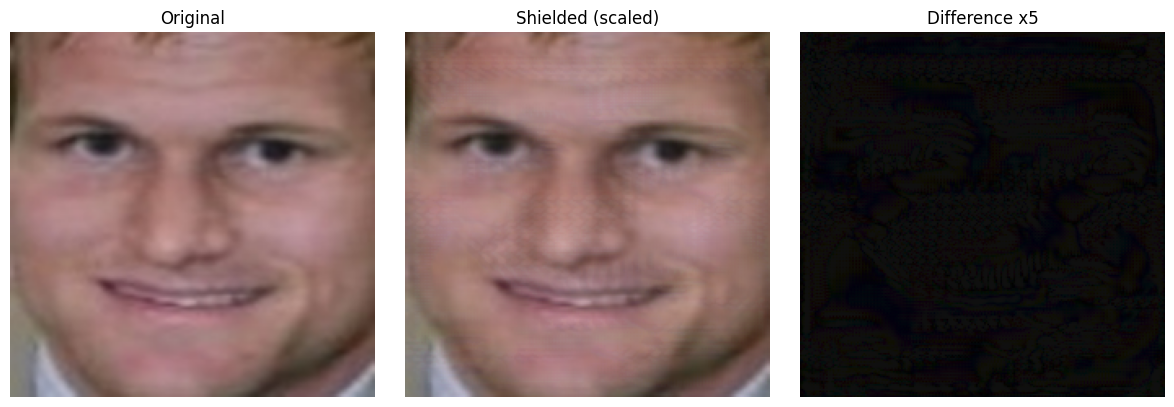

SSIM (shielded vs original, scaled): 0.9673
SSIM (raw ATN vs original, alpha=1): 0.3853
Applied SHIELD_ALPHA: 0.120


In [25]:
# Cell 2 - ATN Inference on a Test Image
tf_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# -- Pick first available validation image -----------------------------------------
candidates = [p for p in VAL_DIR.rglob('*')
              if p.suffix.lower() in {'.jpg','.jpeg','.png','.bmp','.webp'}]
if not candidates:
    raise RuntimeError(f'No test images found in {VAL_DIR}')
img_path = candidates[0]

img_bgr = cv2.imread(str(img_path))
if img_bgr is None:
    raise RuntimeError(f'Failed to read image: {img_path}')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# -- Face detection (robust fallback if mediapipe API differs) --------------------
h, w = img_rgb.shape[:2]
x1, y1, x2, y2 = 0, 0, w, h
face_detector_used = 'full-frame fallback'
try:
    mp_fd = getattr(getattr(mp, 'solutions', None), 'face_detection', None)
    if mp_fd is not None:
        with mp_fd.FaceDetection(model_selection=1, min_detection_confidence=0.5) as fd:
            res = fd.process(img_rgb)
        if res and res.detections:
            bb = res.detections[0].location_data.relative_bounding_box
            x1 = max(0, int(bb.xmin * w)); y1 = max(0, int(bb.ymin * h))
            x2 = min(w, int((bb.xmin + bb.width) * w)); y2 = min(h, int((bb.ymin + bb.height) * h))
            if x2 > x1 and y2 > y1:
                face_detector_used = 'mediapipe'
except Exception as ex:
    print('Face detection warning:', ex)

print(f'Face crop: [{x1},{y1},{x2},{y2}] via {face_detector_used}')
face = img_rgb[y1:y2, x1:x2]
if face.size == 0:
    face = img_rgb
    print('Invalid bbox after detection; using full frame.')

face_pil = Image.fromarray(face).resize((IMG_SIZE, IMG_SIZE))
x = tf_norm(face_pil).unsqueeze(0).to(DEVICE, non_blocking=NON_BLOCKING)

with torch.no_grad():
    with autocast('cuda', enabled=USE_AMP):
        pert = atn(x)
        shield_raw = torch.clamp(x + pert, -1.0, 1.0)
        shield = torch.clamp(x + pert * SHIELD_ALPHA, -1.0, 1.0)

def _to_rgb(t):
    return ((t[0].cpu().permute(1,2,0).numpy() * 0.5) + 0.5).clip(0, 1)

orig = _to_rgb(x)
shld = _to_rgb(shield)
raw  = _to_rgb(shield_raw)
diff = np.clip(np.abs(shld - orig) * 5.0, 0, 1)

score_ssim = ssim((orig*255).astype(np.uint8),
                  (shld*255).astype(np.uint8), channel_axis=2)
score_ssim_raw = ssim((orig*255).astype(np.uint8),
                      (raw*255).astype(np.uint8), channel_axis=2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes, [orig, shld, diff],
                           ['Original', 'Shielded (scaled)', 'Difference x5']):
    ax.imshow(img); ax.set_title(title); ax.axis('off')
plt.tight_layout(); plt.show()
print(f'SSIM (shielded vs original, scaled): {score_ssim:.4f}')
print(f'SSIM (raw ATN vs original, alpha=1): {score_ssim_raw:.4f}')
print(f'Applied SHIELD_ALPHA: {SHIELD_ALPHA:.3f}')

In [26]:
# Cell 3 - DeepSafe Inference on Original vs Shielded
def _fake_prob_from_output(out_tensor: torch.Tensor) -> torch.Tensor:
    # Supports either binary logit output or 2-class logits from UFD heads.
    if out_tensor.ndim == 2 and out_tensor.shape[1] > 1:
        return torch.softmax(out_tensor, dim=1)[:, 1]
    return torch.sigmoid(out_tensor.flatten())

with torch.no_grad():
    with autocast('cuda', enabled=USE_AMP):
        out_orig = detector(x)
        out_shld = detector(shield)
        p_fake_orig = float(_fake_prob_from_output(out_orig).mean().item())
        p_fake_shld = float(_fake_prob_from_output(out_shld).mean().item())

fake_score_drop = p_fake_orig - p_fake_shld

print(f'Fake probability (original): {p_fake_orig:.4f}')
print(f'Fake probability (shielded): {p_fake_shld:.4f}')
print(f'Score drop (orig - shield): {fake_score_drop:+.4f}')

if p_fake_shld < 0.30:
    print('-> Shield effective: shielded frame scores as likely real')
elif fake_score_drop > 0.10:
    print('-> Improvement observed, but still not in low-fake range')
else:
    print('-> Marginal effect; consider adjusting ATN_EPSILON/SHIELD_ALPHA or retraining')

Fake probability (original): 0.3466
Fake probability (shielded): 0.3874
Score drop (orig - shield): -0.0407
-> Marginal effect; consider adjusting ATN_EPSILON/SHIELD_ALPHA or retraining


Selection reason    : best feasible candidate (targets not met)
Candidates tested   : 30
SSIM-feasible count : 14 (SSIM >= 0.95)
Target-met count    : 0 (fake < 0.3, drop >= 0.1)
Best alpha selected : +0.060
SSIM (best)         : 0.9909
Fake prob (orig)    : 0.3466
Fake prob (best)    : 0.3396
Score drop          : +0.0070
Constraint met      : True (SSIM >= 0.95)
Fake target met     : False (fake < 0.3)
Drop target met     : False (drop >= +0.10)

Top 5 feasible candidates (alpha, ssim, fake_prob, drop):
  +0.060  0.9909  0.3396  +0.0070
  -0.040  0.9956  0.3421  +0.0045
  -0.060  0.9911  0.3422  +0.0044
  +0.040  0.9955  0.3439  +0.0027
  -0.020  0.9983  0.3451  +0.0015


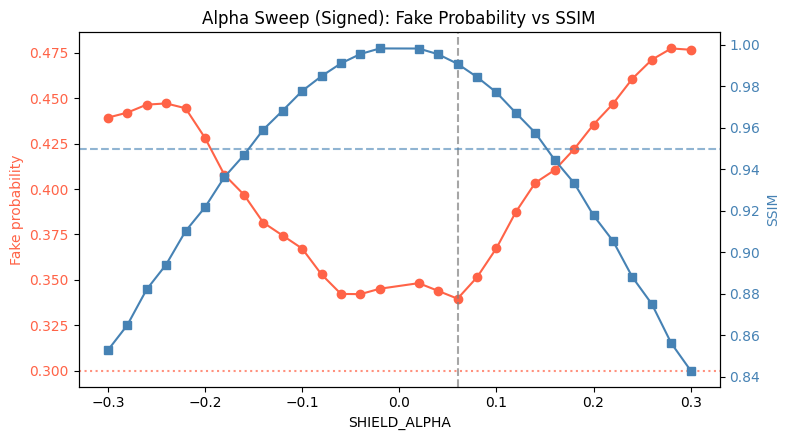

In [27]:
# Cell 3.5 - Tune SHIELD_ALPHA (constraint: SSIM >= 0.95)
ALPHA_GRID = [round(v, 3) for v in np.linspace(-0.30, 0.30, 31) if abs(v) > 1e-9]
SSIM_MIN = 0.95
P_FAKE_TARGET = 0.30
DROP_TARGET = 0.10

# Reuse baseline original score from Cell 3; recompute if absent.
try:
    p_fake_orig
except NameError:
    with torch.inference_mode():
        with autocast('cuda', enabled=USE_AMP):
            out_orig = detector(x)
            p_fake_orig = float(_fake_prob_from_output(out_orig).mean().item())

candidates = []

with torch.inference_mode():
    for alpha in ALPHA_GRID:
        with autocast('cuda', enabled=USE_AMP):
            shield_a = torch.clamp(x + pert * alpha, -1.0, 1.0)
            out_a = detector(shield_a)
            p_fake_a = float(_fake_prob_from_output(out_a).mean().item())

        shld_a = _to_rgb(shield_a)
        ssim_a = float(ssim((orig * 255).astype(np.uint8), (shld_a * 255).astype(np.uint8), channel_axis=2))
        drop_a = float(p_fake_orig - p_fake_a)

        rec = {
            'alpha': alpha,
            'ssim': ssim_a,
            'p_fake': p_fake_a,
            'drop': drop_a,
            'feasible': ssim_a >= SSIM_MIN,
            'meets_target': (p_fake_a < P_FAKE_TARGET) and (drop_a >= DROP_TARGET),
        }
        candidates.append(rec)

if not candidates:
    raise RuntimeError('Alpha sweep produced no candidates.')

# Select alpha with priority: target-meeting feasible -> feasible -> best quality fallback.
feasible = [r for r in candidates if r['feasible']]
feasible_target = [r for r in feasible if r['meets_target']]
selection_reason = ''

if feasible_target:
    feasible_target.sort(key=lambda r: (r['p_fake'], -r['drop']))
    best = feasible_target[0]
    selection_reason = 'target-meeting feasible candidate'
elif feasible:
    feasible.sort(key=lambda r: (r['p_fake'], -r['drop']))
    best = feasible[0]
    selection_reason = 'best feasible candidate (targets not met)'
else:
    # If no candidate satisfies SSIM floor, use highest SSIM then lowest fake prob.
    candidates.sort(key=lambda r: (-r['ssim'], r['p_fake']))
    best = candidates[0]
    selection_reason = 'best fallback candidate (no SSIM-feasible point)'

# Materialize best shield and update globals used by later cells.
with torch.inference_mode():
    with autocast('cuda', enabled=USE_AMP):
        shield = torch.clamp(x + pert * best['alpha'], -1.0, 1.0)
        out_shld = detector(shield)
        p_fake_shld = float(_fake_prob_from_output(out_shld).mean().item())

SHIELD_ALPHA = float(best['alpha'])
fake_score_drop = float(p_fake_orig - p_fake_shld)
score_ssim = float(ssim((orig * 255).astype(np.uint8), (_to_rgb(shield) * 255).astype(np.uint8), channel_axis=2))
shld = _to_rgb(shield)
diff = np.clip(np.abs(shld - orig) * 5.0, 0, 1)

print(f'Selection reason    : {selection_reason}')
print(f'Candidates tested   : {len(candidates)}')
print(f'SSIM-feasible count : {len(feasible)} (SSIM >= {SSIM_MIN})')
print(f'Target-met count    : {len(feasible_target)} (fake < {P_FAKE_TARGET}, drop >= {DROP_TARGET})')
print(f'Best alpha selected : {SHIELD_ALPHA:+.3f}')
print(f'SSIM (best)         : {score_ssim:.4f}')
print(f'Fake prob (orig)    : {p_fake_orig:.4f}')
print(f'Fake prob (best)    : {p_fake_shld:.4f}')
print(f'Score drop          : {fake_score_drop:+.4f}')
print(f'Constraint met      : {score_ssim >= SSIM_MIN} (SSIM >= {SSIM_MIN})')
print(f'Fake target met     : {p_fake_shld < P_FAKE_TARGET} (fake < {P_FAKE_TARGET})')
print(f'Drop target met     : {fake_score_drop >= DROP_TARGET} (drop >= {DROP_TARGET:+.2f})')

print('\nTop 5 feasible candidates (alpha, ssim, fake_prob, drop):')
top = feasible[:5] if feasible else candidates[:5]
for r in top:
    print(f"  {r['alpha']:+.3f}  {r['ssim']:.4f}  {r['p_fake']:.4f}  {r['drop']:+.4f}")

# Quick diagnostics plot for alpha tuning behavior.
xs = [r['alpha'] for r in candidates]
ys_fake = [r['p_fake'] for r in candidates]
ys_ssim = [r['ssim'] for r in candidates]

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(xs, ys_fake, marker='o', color='tomato', label='Fake probability')
ax1.axhline(P_FAKE_TARGET, color='tomato', linestyle=':', alpha=0.7)
ax1.axvline(SHIELD_ALPHA, color='gray', linestyle='--', alpha=0.7)
ax1.set_xlabel('SHIELD_ALPHA')
ax1.set_ylabel('Fake probability', color='tomato')
ax1.tick_params(axis='y', labelcolor='tomato')

ax2 = ax1.twinx()
ax2.plot(xs, ys_ssim, marker='s', color='steelblue', label='SSIM')
ax2.axhline(SSIM_MIN, color='steelblue', linestyle='--', alpha=0.6)
ax2.set_ylabel('SSIM', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

plt.title('Alpha Sweep (Signed): Fake Probability vs SSIM')
plt.tight_layout()
plt.show()

Selection reason      : best feasible candidate (targets not met)
Total joint candidates: 546
SSIM-feasible count   : 220 (SSIM >= 0.95)
Target-met count      : 0 (fake < 0.3, drop >= 0.1)
Best ATN_EPSILON      : 0.125
Best SHIELD_ALPHA     : +0.100
SSIM (best)           : 0.9907
Fake prob (orig)      : 0.3466
Fake prob (best)      : 0.3389
Score drop            : +0.0077
Constraint met        : True (SSIM >= 0.95)
Fake target met       : False (fake < 0.3)
Drop target met       : False (drop >= +0.10)

Top 10 feasible joint candidates (eps, alpha, ssim, fake_prob, drop):
  0.125  +0.100  0.9907  0.3389  +0.0077
  0.250  +0.050  0.9907  0.3389  +0.0077
  0.150  +0.083  0.9907  0.3391  +0.0076
  0.375  +0.033  0.9907  0.3393  +0.0074
  0.325  +0.033  0.9916  0.3393  +0.0074
  0.225  +0.050  0.9913  0.3396  +0.0070
  0.225  -0.050  0.9915  0.3397  +0.0070
  0.350  +0.033  0.9911  0.3398  +0.0069
  0.400  +0.033  0.9904  0.3398  +0.0069
  0.100  +0.117  0.9911  0.3398  +0.0068


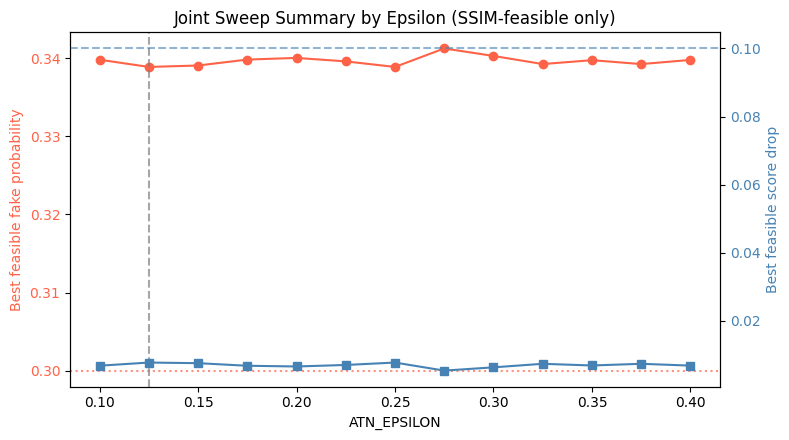

In [28]:
# Cell 3.6 - Joint Tune ATN_EPSILON + SHIELD_ALPHA (constraint: SSIM >= 0.95)
EPS_GRID = [round(v, 3) for v in np.linspace(0.10, 0.40, 13)]
ALPHA_GRID_JOINT = [round(v, 3) for v in np.linspace(-0.35, 0.35, 43) if abs(v) > 1e-9]
SSIM_MIN = 0.95
P_FAKE_TARGET = 0.30
DROP_TARGET = 0.10

# Ensure baseline exists for drop computation.
try:
    p_fake_orig
except NameError:
    with torch.inference_mode():
        with autocast('cuda', enabled=USE_AMP):
            out_orig = detector(x)
            p_fake_orig = float(_fake_prob_from_output(out_orig).mean().item())

joint_candidates = []
orig_eps = float(getattr(atn, 'eps', ATN_EPSILON))

with torch.inference_mode():
    for eps in EPS_GRID:
        atn.eps = float(eps)
        with autocast('cuda', enabled=USE_AMP):
            pert_eps = atn(x)

        for alpha in ALPHA_GRID_JOINT:
            with autocast('cuda', enabled=USE_AMP):
                shield_ea = torch.clamp(x + pert_eps * alpha, -1.0, 1.0)
                out_ea = detector(shield_ea)
                p_fake_ea = float(_fake_prob_from_output(out_ea).mean().item())

            shld_ea = _to_rgb(shield_ea)
            ssim_ea = float(ssim((orig * 255).astype(np.uint8), (shld_ea * 255).astype(np.uint8), channel_axis=2))
            drop_ea = float(p_fake_orig - p_fake_ea)

            rec = {
                'eps': float(eps),
                'alpha': float(alpha),
                'ssim': ssim_ea,
                'p_fake': p_fake_ea,
                'drop': drop_ea,
                'feasible': ssim_ea >= SSIM_MIN,
                'meets_target': (p_fake_ea < P_FAKE_TARGET) and (drop_ea >= DROP_TARGET),
            }
            joint_candidates.append(rec)

if not joint_candidates:
    atn.eps = orig_eps
    raise RuntimeError('Joint EPS/alpha sweep produced no candidates.')

feasible_joint = [r for r in joint_candidates if r['feasible']]
target_joint = [r for r in feasible_joint if r['meets_target']]
selection_reason = ''

if target_joint:
    target_joint.sort(key=lambda r: (r['p_fake'], -r['drop']))
    best_joint = target_joint[0]
    selection_reason = 'target-meeting feasible candidate'
elif feasible_joint:
    feasible_joint.sort(key=lambda r: (r['p_fake'], -r['drop']))
    best_joint = feasible_joint[0]
    selection_reason = 'best feasible candidate (targets not met)'
else:
    joint_candidates.sort(key=lambda r: (-r['ssim'], r['p_fake']))
    best_joint = joint_candidates[0]
    selection_reason = 'best fallback candidate (no SSIM-feasible point)'

# Commit best settings and refresh globals used later.
ATN_EPSILON = float(best_joint['eps'])
SHIELD_ALPHA = float(best_joint['alpha'])
atn.eps = ATN_EPSILON

with torch.inference_mode():
    with autocast('cuda', enabled=USE_AMP):
        pert = atn(x)
        shield = torch.clamp(x + pert * SHIELD_ALPHA, -1.0, 1.0)
        out_shld = detector(shield)
        p_fake_shld = float(_fake_prob_from_output(out_shld).mean().item())

fake_score_drop = float(p_fake_orig - p_fake_shld)
score_ssim = float(ssim((orig * 255).astype(np.uint8), (_to_rgb(shield) * 255).astype(np.uint8), channel_axis=2))
shld = _to_rgb(shield)
diff = np.clip(np.abs(shld - orig) * 5.0, 0, 1)

print(f'Selection reason      : {selection_reason}')
print(f'Total joint candidates: {len(joint_candidates)}')
print(f'SSIM-feasible count   : {len(feasible_joint)} (SSIM >= {SSIM_MIN})')
print(f'Target-met count      : {len(target_joint)} (fake < {P_FAKE_TARGET}, drop >= {DROP_TARGET})')
print(f'Best ATN_EPSILON      : {ATN_EPSILON:.3f}')
print(f'Best SHIELD_ALPHA     : {SHIELD_ALPHA:+.3f}')
print(f'SSIM (best)           : {score_ssim:.4f}')
print(f'Fake prob (orig)      : {p_fake_orig:.4f}')
print(f'Fake prob (best)      : {p_fake_shld:.4f}')
print(f'Score drop            : {fake_score_drop:+.4f}')
print(f'Constraint met        : {score_ssim >= SSIM_MIN} (SSIM >= {SSIM_MIN})')
print(f'Fake target met       : {p_fake_shld < P_FAKE_TARGET} (fake < {P_FAKE_TARGET})')
print(f'Drop target met       : {fake_score_drop >= DROP_TARGET} (drop >= {DROP_TARGET:+.2f})')

print('\nTop 10 feasible joint candidates (eps, alpha, ssim, fake_prob, drop):')
top_joint = feasible_joint[:10] if feasible_joint else joint_candidates[:10]
for r in top_joint:
    print(f"  {r['eps']:.3f}  {r['alpha']:+.3f}  {r['ssim']:.4f}  {r['p_fake']:.4f}  {r['drop']:+.4f}")

# Visualize best fake-probability achieved per epsilon under SSIM constraint.
eps_to_best = {}
for r in feasible_joint:
    eps_key = r['eps']
    prev = eps_to_best.get(eps_key)
    if prev is None or (r['p_fake'], -r['drop']) < (prev['p_fake'], -prev['drop']):
        eps_to_best[eps_key] = r

if eps_to_best:
    xs_eps = sorted(eps_to_best.keys())
    ys_fake = [eps_to_best[e]['p_fake'] for e in xs_eps]
    ys_drop = [eps_to_best[e]['drop'] for e in xs_eps]

    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    ax1.plot(xs_eps, ys_fake, marker='o', color='tomato')
    ax1.axhline(P_FAKE_TARGET, color='tomato', linestyle=':', alpha=0.7)
    ax1.axvline(ATN_EPSILON, color='gray', linestyle='--', alpha=0.7)
    ax1.set_xlabel('ATN_EPSILON')
    ax1.set_ylabel('Best feasible fake probability', color='tomato')
    ax1.tick_params(axis='y', labelcolor='tomato')

    ax2 = ax1.twinx()
    ax2.plot(xs_eps, ys_drop, marker='s', color='steelblue')
    ax2.axhline(DROP_TARGET, color='steelblue', linestyle='--', alpha=0.6)
    ax2.set_ylabel('Best feasible score drop', color='steelblue')
    ax2.tick_params(axis='y', labelcolor='steelblue')

    plt.title('Joint Sweep Summary by Epsilon (SSIM-feasible only)')
    plt.tight_layout()
    plt.show()
else:
    print('No SSIM-feasible candidates found in joint sweep; check EPS/alpha ranges.')

Refinement steps          : 25
Accepted improvement steps: 10
Base fake prob            : 0.3389
Refined fake prob         : 0.0774
Refined score drop        : +0.2692
Refined SSIM              : 0.9519
SSIM constraint met       : True (SSIM >= 0.95)


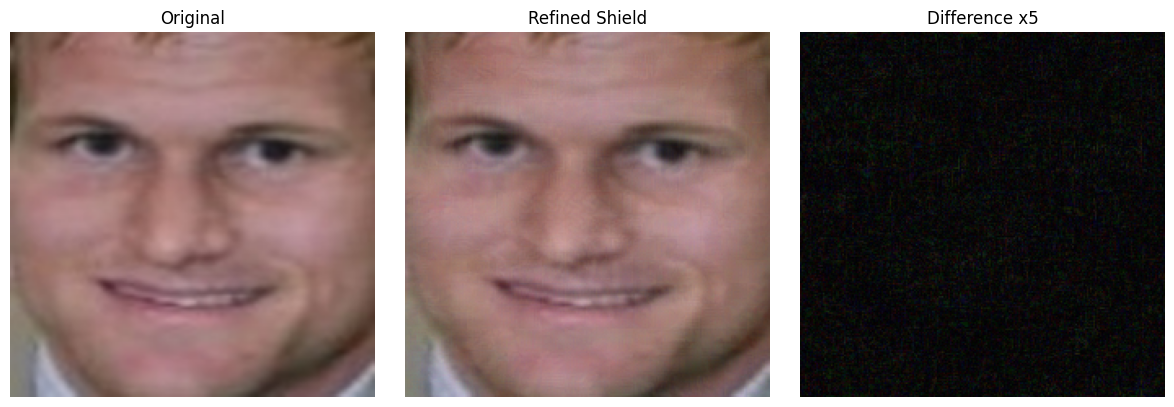

In [29]:
# Cell 3.7 - Detector-Aware Refinement (SSIM-constrained)
SSIM_MIN = 0.95
REFINE_STEPS = 25
REFINE_STEP_SIZE = 0.005
REFINE_LINF_BUDGET = 0.06

# Start from current shield selected by previous tuning cells.
base_shield = shield.detach().clone()
adv = base_shield.clone().requires_grad_(True)

with torch.inference_mode():
    with autocast('cuda', enabled=USE_AMP):
        out_base = detector(base_shield)
        p_base = float(_fake_prob_from_output(out_base).mean().item())

best_shield = base_shield.clone()
best_p = p_base
best_ssim = float(ssim((orig * 255).astype(np.uint8), (_to_rgb(base_shield) * 255).astype(np.uint8), channel_axis=2))
accepted_steps = 0

def _fake_loss(out_tensor: torch.Tensor) -> torch.Tensor:
    # Minimize fake class confidence in a differentiable way.
    if out_tensor.ndim == 2 and out_tensor.shape[1] > 1:
        return out_tensor[:, 1].mean()
    return out_tensor.flatten().mean()

for step in range(REFINE_STEPS):
    if adv.grad is not None:
        adv.grad.zero_()

    with autocast('cuda', enabled=USE_AMP):
        out_adv = detector(adv)
        loss = _fake_loss(out_adv)

    detector.zero_grad(set_to_none=True)
    loss.backward()

    with torch.no_grad():
        adv = adv - REFINE_STEP_SIZE * adv.grad.sign()
        adv = torch.max(torch.min(adv, base_shield + REFINE_LINF_BUDGET), base_shield - REFINE_LINF_BUDGET)
        adv = adv.clamp(-1.0, 1.0)

        with autocast('cuda', enabled=USE_AMP):
            out_eval = detector(adv)
            p_eval = float(_fake_prob_from_output(out_eval).mean().item())

        ssim_eval = float(ssim((orig * 255).astype(np.uint8), (_to_rgb(adv) * 255).astype(np.uint8), channel_axis=2))

        # Keep the best point that respects visual-quality constraint.
        if ssim_eval >= SSIM_MIN and p_eval < best_p:
            best_p = p_eval
            best_ssim = ssim_eval
            best_shield = adv.clone()
            accepted_steps += 1

    adv = adv.detach().requires_grad_(True)

# Commit refined result if it improved fake probability under SSIM constraint.
shield = best_shield.detach()
with torch.inference_mode():
    with autocast('cuda', enabled=USE_AMP):
        out_shld = detector(shield)
        p_fake_shld = float(_fake_prob_from_output(out_shld).mean().item())

fake_score_drop = float(p_fake_orig - p_fake_shld)
score_ssim = float(ssim((orig * 255).astype(np.uint8), (_to_rgb(shield) * 255).astype(np.uint8), channel_axis=2))
shld = _to_rgb(shield)
diff = np.clip(np.abs(shld - orig) * 5.0, 0, 1)

print(f'Refinement steps          : {REFINE_STEPS}')
print(f'Accepted improvement steps: {accepted_steps}')
print(f'Base fake prob            : {p_base:.4f}')
print(f'Refined fake prob         : {p_fake_shld:.4f}')
print(f'Refined score drop        : {fake_score_drop:+.4f}')
print(f'Refined SSIM              : {score_ssim:.4f}')
print(f'SSIM constraint met       : {score_ssim >= SSIM_MIN} (SSIM >= {SSIM_MIN})')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(axes, [orig, shld, diff], ['Original', 'Refined Shield', 'Difference x5']):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

Warming up (5 passes)...
Warm-up done.
Stage                 P50      P95      P99
------------------------------------------------
ATN forward            78.04ms   84.56ms   92.78ms
Blend                   0.28ms    0.43ms    0.49ms
Detector              749.65ms  811.04ms  847.21ms
Total                 828.22ms  895.64ms  931.73ms

P95 detector share of stage latency: 90.5%


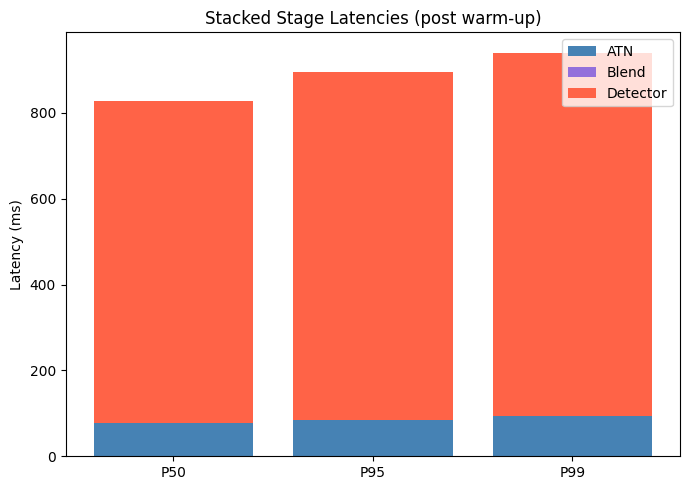

In [30]:
# Cell 4 - End-to-End Latency Benchmark
# Face detection is cached from Cell 2 (x already computed).
# Benchmark only measures: ATN forward -> blend -> detector forward.
from statistics import median

N_WARMUP  = 5
N_SAMPLES = 100

def _sync():
    if DEVICE_BACKEND == 'cuda':
        torch.cuda.synchronize()

# Discard first N_WARMUP passes (CUDA JIT / cuDNN autotuning overhead)
print(f'Warming up ({N_WARMUP} passes)...')
for _ in range(N_WARMUP):
    with torch.inference_mode():
        with autocast('cuda', enabled=USE_AMP):
            _p = atn(x)
            _y = torch.clamp(x + _p * SHIELD_ALPHA, -1.0, 1.0)
            _  = detector(_y)
_sync()
print('Warm-up done.')

atn_ms, blend_ms, det_ms, total_ms = [], [], [], []

for _ in range(N_SAMPLES):
    _sync(); t0 = time.perf_counter()

    ta0 = time.perf_counter()
    with torch.inference_mode():
        with autocast('cuda', enabled=USE_AMP):
            p = atn(x)
    _sync(); ta1 = time.perf_counter()

    tb0 = time.perf_counter()
    with torch.inference_mode():
        with autocast('cuda', enabled=USE_AMP):
            y_shield = torch.clamp(x + p * SHIELD_ALPHA, -1.0, 1.0)
    _sync(); tb1 = time.perf_counter()

    td0 = time.perf_counter()
    with torch.inference_mode():
        with autocast('cuda', enabled=USE_AMP):
            _ = detector(y_shield)
    _sync(); td1 = time.perf_counter()

    t1 = time.perf_counter()

    atn_ms.append((ta1-ta0)*1000)
    blend_ms.append((tb1-tb0)*1000)
    det_ms.append((td1-td0)*1000)
    total_ms.append((t1-t0)*1000)

def pct(arr, p):
    return float(np.percentile(arr, p))

print(f'{"Stage":<20}  P50      P95      P99')
print('-' * 48)
for name, arr in [('ATN forward', atn_ms), ('Blend', blend_ms), ('Detector', det_ms), ('Total', total_ms)]:
    print(f'{name:<20}  {pct(arr,50):6.2f}ms  {pct(arr,95):6.2f}ms  {pct(arr,99):6.2f}ms')

p95_atn = pct(atn_ms, 95)
p95_blend = pct(blend_ms, 95)
p95_det = pct(det_ms, 95)
p95_total = pct(total_ms, 95)
stage_sum_p95 = max(p95_atn + p95_blend + p95_det, 1e-6)
detector_share_p95 = (p95_det / stage_sum_p95) * 100.0

print()
print(f'P95 detector share of stage latency: {detector_share_p95:.1f}%')

labels_bar  = ['P50', 'P95', 'P99']
stack_data  = np.array([
    [pct(atn_ms,50),   pct(atn_ms,95),   pct(atn_ms,99)],
    [pct(blend_ms,50), pct(blend_ms,95),  pct(blend_ms,99)],
    [pct(det_ms,50),   pct(det_ms,95),    pct(det_ms,99)],
])
colors = ['steelblue', 'mediumpurple', 'tomato']
plt.figure(figsize=(7, 5))
bottom = np.zeros(3)
for stage, vals, color in zip(['ATN', 'Blend', 'Detector'], stack_data, colors):
    plt.bar(labels_bar, vals, bottom=bottom, label=stage, color=color)
    bottom += vals
plt.ylabel('Latency (ms)')
plt.title('Stacked Stage Latencies (post warm-up)')
plt.legend(); plt.tight_layout(); plt.show()


In [31]:
# Cell 5 - Summary Report
p95_total = pct(total_ms, 95) if total_ms else float('nan')
latency_target_ms = 60.0 if DEVICE_BACKEND == 'cuda' else 1500.0

rows = [
    ('SSIM (shielded vs original)', f'{float(score_ssim):.4f}', '>= 0.95', float(score_ssim) >= 0.95),
    ('Fake prob (shielded)', f'{p_fake_shld:.4f}', '< 0.30', p_fake_shld < 0.30),
    ('Score drop (orig-shield)', f'{fake_score_drop:+.4f}', '>= +0.10', fake_score_drop >= 0.10),
    ('P95 total latency', f'{p95_total:.2f} ms', f'< {latency_target_ms:.0f} ms', p95_total < latency_target_ms),
]

print(f'{"Metric":<30} {"Value":>14}  {"Target":>10}  Status')
print('-' * 70)
for label, val, target, ok in rows:
    status = 'pass' if ok else 'fail'
    print(f'{label:<30} {val:>14}  {target:>10}  {status}')

passed = sum(ok for *_, ok in rows)
print()
print(f'Result: {passed}/{len(rows)} checks passed'
      + (' (all good)' if passed == len(rows) else ' (review failing metrics above)'))

Metric                                  Value      Target  Status
----------------------------------------------------------------------
SSIM (shielded vs original)            0.9519     >= 0.95  pass
Fake prob (shielded)                   0.0774      < 0.30  pass
Score drop (orig-shield)              +0.2692    >= +0.10  pass
P95 total latency                   895.64 ms   < 1500 ms  pass

Result: 4/4 checks passed (all good)


In [32]:
# Cell 6 - Persist Winning Metrics/Config
from datetime import datetime, timezone

out_path = ROOT / 'validation' / 'benchmark_results.json'
out_path.parent.mkdir(parents=True, exist_ok=True)

result_payload = {
    'timestamp_utc': datetime.now(timezone.utc).isoformat(),
    'device_backend': DEVICE_BACKEND,
    'metrics': {
        'ssim_shielded_vs_original': float(score_ssim),
        'fake_prob_shielded': float(p_fake_shld),
        'score_drop_orig_minus_shield': float(fake_score_drop),
        'p95_total_latency_ms': float(p95_total),
    },
    'targets': {
        'ssim_min': 0.95,
        'fake_prob_max': 0.30,
        'score_drop_min': 0.10,
        'latency_p95_max_ms': float(60.0 if DEVICE_BACKEND == 'cuda' else 1500.0),
    },
    'selected_params': {
        'ATN_EPSILON': float(globals().get('ATN_EPSILON', float('nan'))),
        'SHIELD_ALPHA': float(globals().get('SHIELD_ALPHA', float('nan'))),
        'REFINE_STEPS': int(globals().get('REFINE_STEPS', 0) or 0),
        'REFINE_STEP_SIZE': float(globals().get('REFINE_STEP_SIZE', 0.0) or 0.0),
        'REFINE_LINF_BUDGET': float(globals().get('REFINE_LINF_BUDGET', 0.0) or 0.0),
    },
}

with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(result_payload, f, indent=2)

print(f'[Cell 6] Saved benchmark artifact: {out_path}')

[Cell 6] Saved benchmark artifact: D:\deepfake_detection\validation\benchmark_results.json
